# **Project Title  :   "Air Quality Index (AQI) Prediction and Health Impact Analysis Using Machine Learning."**

## **Introduction**

Air pollution is one of the most serious environmental issues affecting public health. The Air Quality Index (AQI) is used to measure and communicate air pollution levels. This project focuses on calculating AQI using CPCB guidelines, analyzing pollutant impact, and predicting AQI using Machine Learning models.

## **Problem Statement:**
**The objective of this project is to analyze air pollutant data and identify the most influential pollutant affecting AQI. A Machine Learning model is developed to predict this dominant pollutant concentration using other pollutant parameters. The predicted value is then used to calculate AQI using CPCB standards, ensuring a meaningful and practical application of Machine Learning.**

## **Project Objective**

The objective of this project is to analyze air pollution data and build machine learning models to predict most influential pollutant affecting AQI based on other pollutant parameters.

The goal is to:
- Perform Exploratory Data Analysis (EDA)
- Understand relationships between pollutants
- Build predictive models
- Compare model performances
- Identify the most important factors affecting PM2.5

In [ ]:
# Importing

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## **Importing Dataset**

**Source of Data**

The dataset is obtained from the Central Pollution Control Board (CPCB) through the
Open Government Data Platform India, air quality monitoring system and publicly available environmental datasets.

link :
https://www.data.gov.in/resource/real-time-air-quality-index-various-locations

In [ ]:
df1 = pd.read_excel("AQI_DATA.xlsx")

# First 5 rows
df1.head()



,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Assam,Byrnihat,"Central Academy for SFS, Byrnihat - PCBA",2026-02-14 20:00:00,26.071318,91.874880,PM2.5,87.0,376.0,164.0
1,India,Assam,Byrnihat,"Central Academy for SFS, Byrnihat - PCBA",2026-02-14 20:00:00,26.071318,91.874880,NO2,4.0,10.0,7.0
2,India,Assam,Byrnihat,"Central Academy for SFS, Byrnihat - PCBA",2026-02-14 20:00:00,26.071318,91.874880,NH3,4.0,5.0,4.0
3,India,Assam,Guwahati,"LGBI Airport, Guwahati - PCBA",2026-02-14 20:00:00,26.108870,91.589544,OZONE,9.0,14.0,13.0
4,India,Assam,Guwahati,"Railway Colony, Guwahati - PCBA",2026-02-14 20:00:00,26.181742,91.780630,PM2.5,177.0,369.0,304.0


# **Converting Long Data Into Wide Data**

The original dataset was in long format, where each row contained only one pollutant measurement. However, AQI calculation requires multiple pollutant concentrations (PM2.5, PM10, NO₂, SO₂, CO, OZONE) to be available together for a single city and time.

Therefore, the dataset was converted into wide format so that each pollutant appears as a separate column. This structure is necessary for accurate AQI computation, correlation analysis, and machine learning model development.

In [ ]:
# convert into wide format
df= df1.pivot_table(
    index=['country',	'state','city','station','last_update'],
    columns='pollutant_id',
    values='pollutant_avg'
).reset_index()

df.head()

pollutant_id,country,state,city,station,last_update,CO,NH3,NO2,OZONE,PM10,PM2.5,SO2
0,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",2026-02-14 20:00:00,38.0,5.0,51.0,58.0,164.0,111.0,17.0
1,India,Andhra_Pradesh,Anantapur,"Gulzarpet, Anantapur - APPCB",2026-02-14 20:00:00,31.0,5.0,21.0,17.0,76.0,86.0,8.0
2,India,Andhra_Pradesh,Chittoor,"Gangineni Cheruvu, Chittoor - APPCB",2026-02-14 20:00:00,36.0,3.0,13.0,69.0,51.0,56.0,11.0
3,India,Andhra_Pradesh,Kadapa,"Yerramukkapalli, Kadapa - APPCB",2026-02-14 20:00:00,11.0,4.0,21.0,14.0,92.0,72.0,12.0
4,India,Andhra_Pradesh,Rajamahendravaram,"Anand Kala Kshetram, Rajamahendravaram - APPCB",2026-02-14 20:00:00,33.0,5.0,36.0,31.0,115.0,105.0,12.0


In [ ]:
# Last 5 Rows
df.tail()

pollutant_id,country,state,city,station,last_update,CO,NH3,NO2,OZONE,PM10,PM2.5,SO2
479,India,West_Bengal,Kolkata,"Jadavpur, Kolkata - WBPCB",2026-02-14 20:00:00,36.0,8.0,43.0,22.0,152.0,216.0,4.0
480,India,West_Bengal,Kolkata,"Rabindra Bharati University, Kolkata - WBPCB",2026-02-14 20:00:00,47.0,12.0,122.0,36.0,159.0,224.0,9.0
481,India,West_Bengal,Kolkata,"Rabindra Sarobar, Kolkata - WBPCB",2026-02-14 20:00:00,44.0,22.0,117.0,26.0,115.0,148.0,32.0
482,India,West_Bengal,Kolkata,"Victoria, Kolkata - WBPCB",2026-02-14 20:00:00,34.0,8.0,68.0,43.0,152.0,156.0,26.0
483,India,West_Bengal,Siliguri,"Ward-32 Bapupara, Siliguri - WBPCB",2026-02-14 20:00:00,49.0,10.0,18.0,104.0,140.0,128.0,16.0


**=> Details About Dataset**

In [ ]:
# total rows and columns
print("Number of Rows : ", df.shape[0])
print("Number of Columns : ", df.shape[1])
df.shape


Number of Rows :  484
Number of Columns :  12


(484, 12)

In [ ]:
# columns names

print("Total Columns in Dataset :")
for col in df.columns:
    print(col)


Total Columns in Dataset :
country
state
city
station
last_update
CO
NH3
NO2
OZONE
PM10
PM2.5
SO2


In [ ]:
print("\nData Types :\n ")
df.info()



Data Types :
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484 entries, 0 to 483
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   country      484 non-null    object        
 1   state        484 non-null    object        
 2   city         484 non-null    object        
 3   station      484 non-null    object        
 4   last_update  484 non-null    datetime64[ns]
 5   CO           465 non-null    float64       
 6   NH3          399 non-null    float64       
 7   NO2          443 non-null    float64       
 8   OZONE        454 non-null    float64       
 9   PM10         446 non-null    float64       
 10  PM2.5        449 non-null    float64       
 11  SO2          432 non-null    float64       
dtypes: datetime64[ns](1), float64(7), object(4)
memory usage: 45.5+ KB


**=> Identify Quantitative & Qualitative Columns**

In [ ]:
# Identify numerical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Quantitative Columns:\n")
print(list(numeric_cols))


Quantitative Columns:

['CO', 'NH3', 'NO2', 'OZONE', 'PM10', 'PM2.5', 'SO2']


In [ ]:
# Identify categorical columns
categorycal_cols = df.select_dtypes(include=['object']).columns
print("Qualitative Columns:\n")
print(list(categorycal_cols))


Qualitative Columns:

['country', 'state', 'city', 'station']


In [ ]:
# identify date columns
date_cols = df.select_dtypes(include=['datetime64']).columns
print("Datetime Columns:\n")
print(list(date_cols))


Datetime Columns:

['last_update']


# **Data Cleaning**

**=> Check Missing Values**

In [ ]:
# check data is missing or not.
df.isnull().sum()


,0
pollutant_id,
country,0
state,0
city,0
station,0
last_update,0
CO,19
NH3,85
NO2,41
OZONE,30


In [ ]:
# handling missing values
pollutants = ['CO','NH3','NO2','OZONE','PM10','PM2.5','SO2']

for col in pollutants:
    df[col].fillna(df[col].median(), inplace=True)

# again check mif there is any missing valu
df.isnull().sum()



/tmp/ipykernel_663/9780816.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


,0
pollutant_id,
country,0
state,0
city,0
station,0
last_update,0
CO,0
NH3,0
NO2,0
OZONE,0


Missing pollutant values were replaced using the median method to reduce the impact of extreme values and maintain data distribution. This ensures better performance in AQI prediction modeling.

**=> Check Duplicate Records**

In [ ]:
# identify duplicate rows

df.duplicated().sum()



np.int64(0)

It means there are no duplicate records in dataset.

**=> Check Pollution values is negative or not.**

In [ ]:
# check any columns has negative value
pollutants = ['CO','NH3','NO2','OZONE','PM10','PM2.5','SO2']

for col in pollutants:
    print(col, "Negative Values:", (df[col] < 0).sum())


CO Negative Values: 0
NH3 Negative Values: 0
NO2 Negative Values: 0
OZONE Negative Values: 0
PM10 Negative Values: 0
PM2.5 Negative Values: 0
SO2 Negative Values: 0


There are no logically invalid values in dataset.

## **Column Classification (Feature Types)**

The dataset columns are categorized based on their data type:

| Column | Type |
|------|------|
| City | Nominal |
| PM2.5 | Continuous |
| PM10 | Continuous |
| NO2 | Continuous |
| SO2 | Continuous |
| CO | Continuous |
| NH3 | Continuous |
| O3 | Continuous |

# **Exploratory Data Analysis (EDA)**

## **1. Statistical**

**=> Descriptive Statistics**

In [ ]:
df[pollutants].describe()


pollutant_id,CO,NH3,NO2,OZONE,PM10,PM2.5,SO2
count,484.000000,484.000000,484.000000,484.000000,484.000000,484.000000,484.000000
mean,37.832645,6.590909,36.136364,49.857438,119.150826,116.743802,16.245868
std,22.005620,4.642722,26.815874,37.768478,45.709916,64.332570,12.574724
min,2.000000,1.000000,1.000000,1.000000,21.000000,2.000000,1.000000
25%,23.000000,4.000000,16.000000,22.000000,92.000000,70.750000,8.000000
50%,34.000000,6.000000,30.000000,39.000000,114.500000,101.000000,13.000000
75%,47.250000,8.000000,49.000000,73.000000,139.250000,150.000000,20.000000
max,154.000000,31.000000,136.000000,263.000000,298.000000,329.000000,127.000000


**=> Statistical Measures**

In [ ]:
# calculate mean

df[pollutants].mean()

,0
pollutant_id,
CO,37.832645
NH3,6.590909
NO2,36.136364
OZONE,49.857438
PM10,119.150826
PM2.5,116.743802
SO2,16.245868


The mean values indicate the overall average concentration of each pollutant in the dataset.

In [ ]:
# calculate median
df[pollutants].median()

,0
pollutant_id,
CO,34.0
NH3,6.0
NO2,30.0
OZONE,39.0
PM10,114.5
PM2.5,101.0
SO2,13.0


The median represents the central pollution value and helps understand the typical air quality level.

In [ ]:
# calculate standared deviation

df[pollutants].std()

,0
pollutant_id,
CO,22.005620
NH3,4.642722
NO2,26.815874
OZONE,37.768478
PM10,45.709916
PM2.5,64.332570
SO2,12.574724


Standard Deviation shows how much pollution levels vary across different locations and time.

In [ ]:
# Skewness (Shape of Distribution)
df[pollutants].skew()

,0
pollutant_id,
CO,1.461997
NH3,1.740712
NO2,1.265309
OZONE,1.372947
PM10,0.890897
PM2.5,0.954797
SO2,2.658426


Most pollutants show positive skewness, indicating occasional high pollution spikes.

In [ ]:
# Kurtosis (Extreme Values)
df[pollutants].kurt()

,0
pollutant_id,
CO,3.405624
NH3,4.267613
NO2,1.309952
OZONE,2.660707
PM10,1.435274
PM2.5,0.292960
SO2,14.320730


High kurtosis suggests the presence of extreme pollution days, which are important for health impact analysis.

## **2. Graphical**

## **=> Univariate Analysis**

**1. Histogram (Distribution of Each Pollutant)**

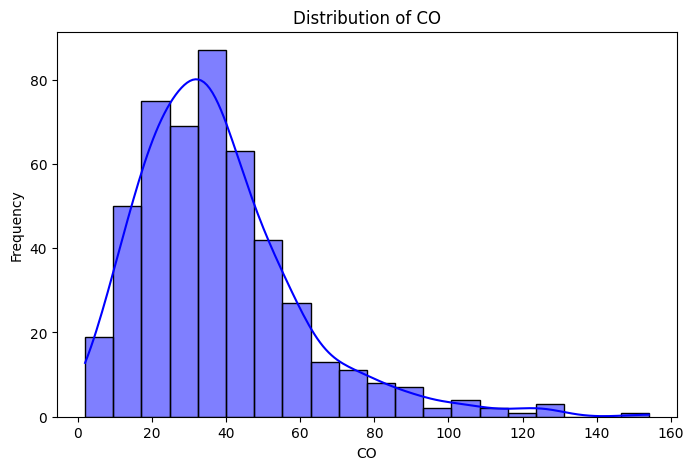

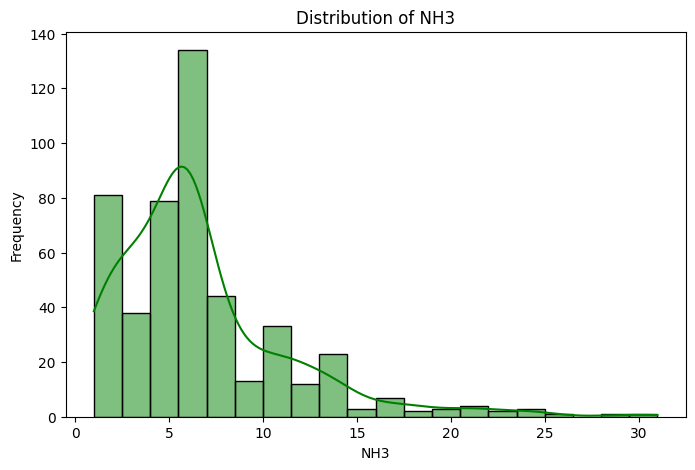

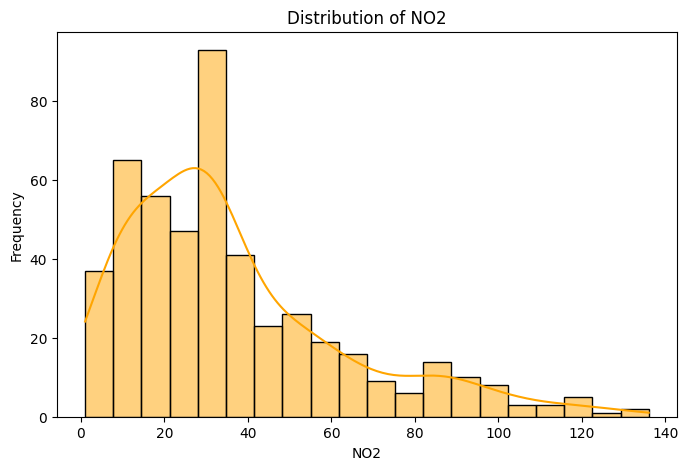

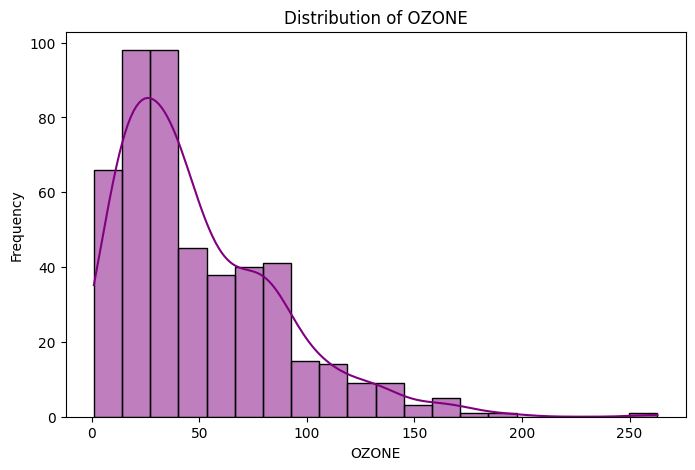

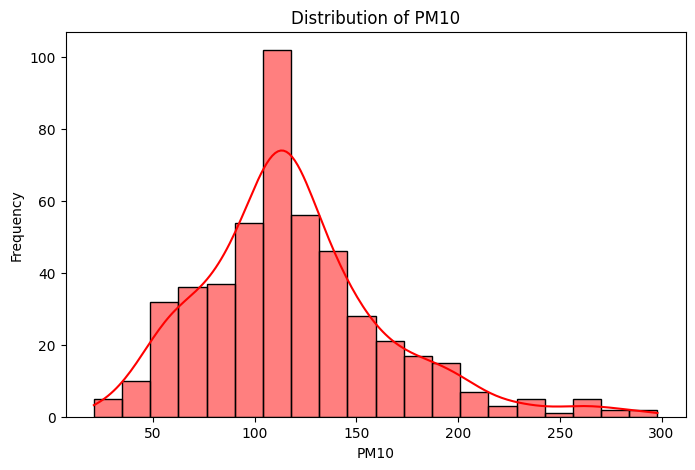

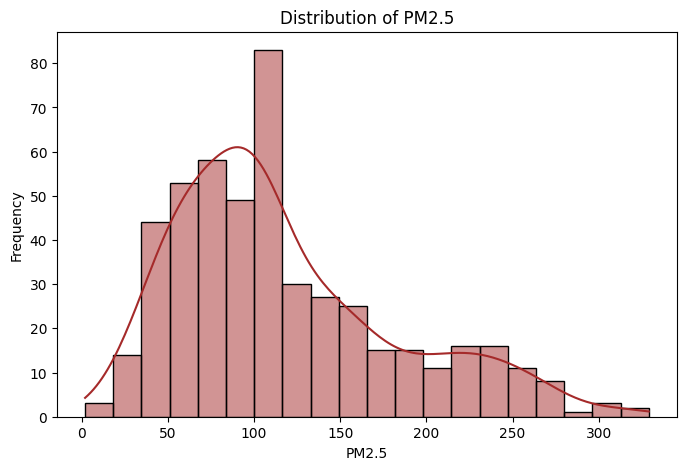

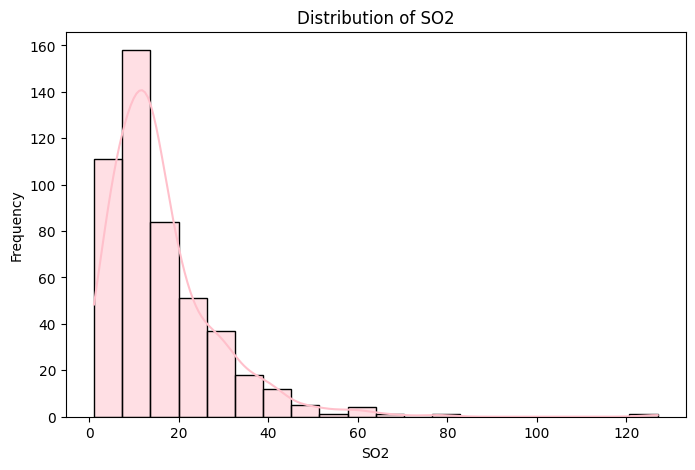

In [ ]:
# histograms

pollutants = ['CO','NH3','NO2','OZONE','PM10','PM2.5','SO2']
colors = ['blue','green','orange','purple','red','brown','pink']

for col, color in zip(pollutants, colors):
    plt.figure(figsize=(8,5))
    sns.histplot(df[col], bins=20, kde=True, color=color)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


The histograms show that all pollutants are positively skewed, meaning most values are in the low to moderate range, but a few very high values create a long right tail. This indicates occasional extreme pollution events and the presence of outliers. The data is not normally distributed and shows variability across different monitoring stations.

**2. Boxplot**

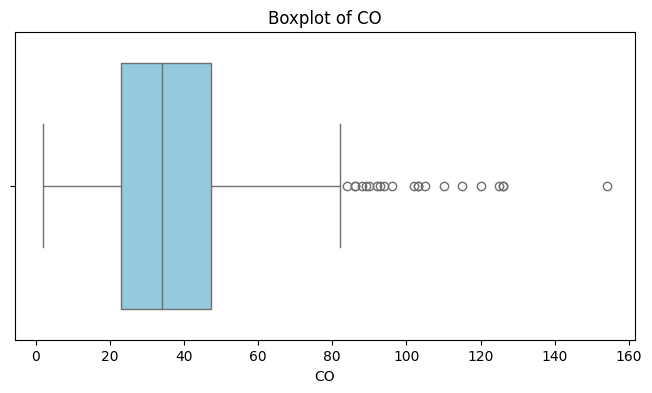

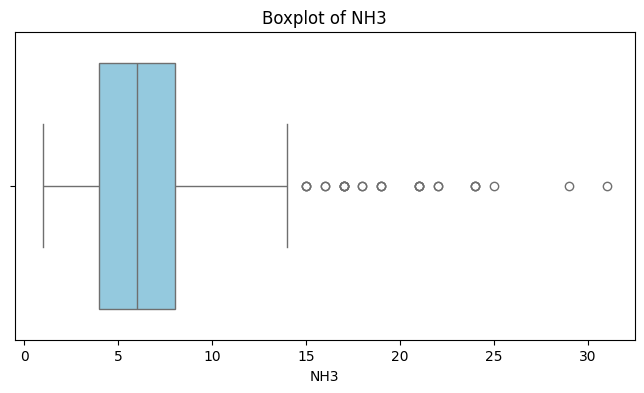

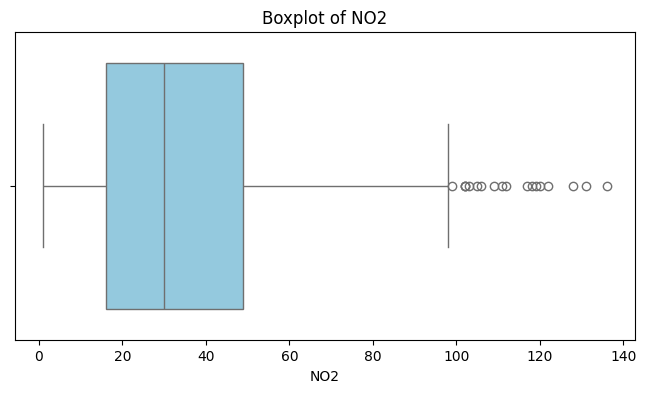

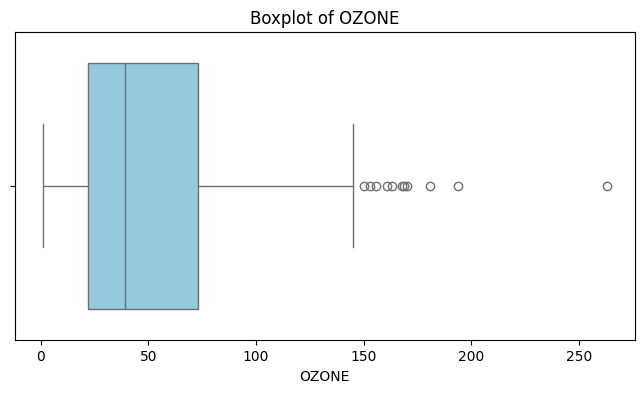

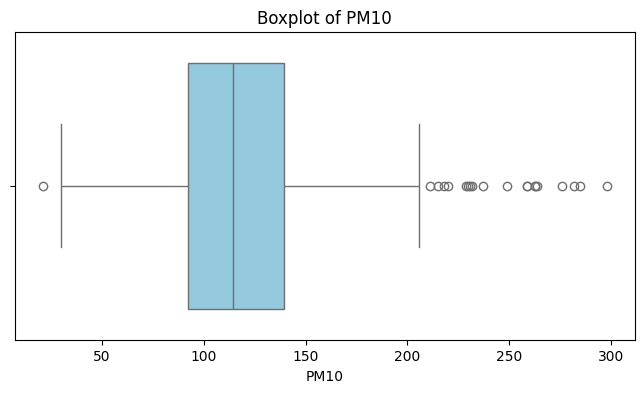

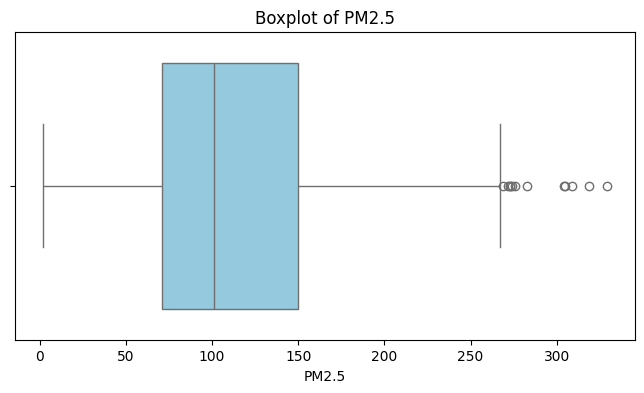

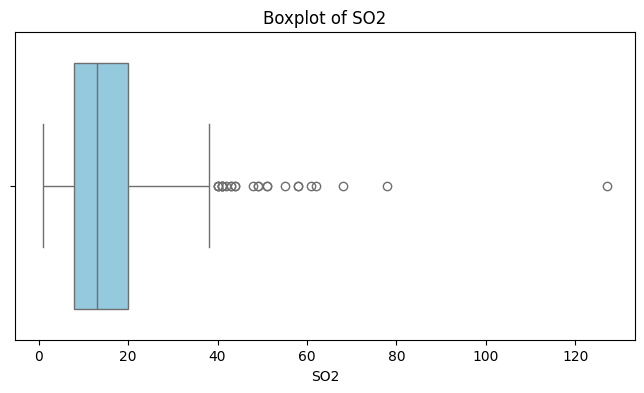

In [ ]:
# boxplots

for col in pollutants:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f"Boxplot of {col}")
    plt.show()

Boxplots reveal significant outliers in PM2.5 and PM10, suggesting extreme pollution episodes in certain cities.

**3. Violin Plot**

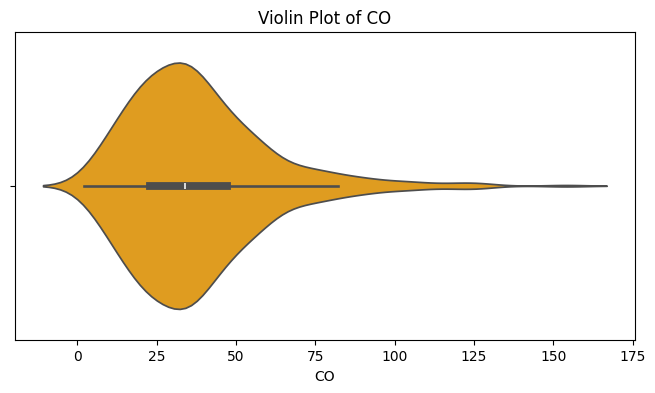

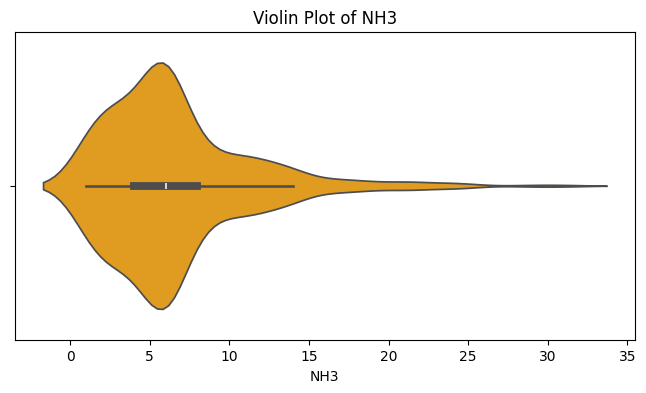

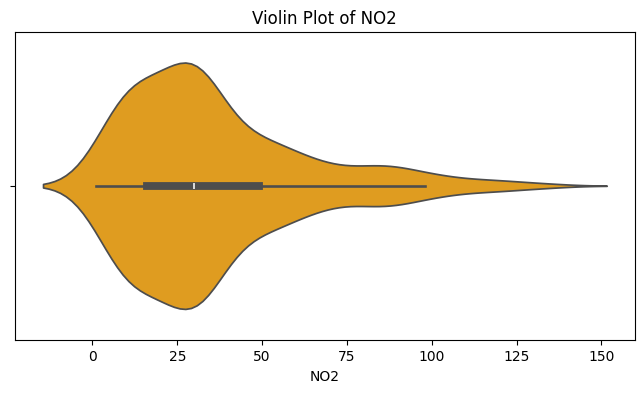

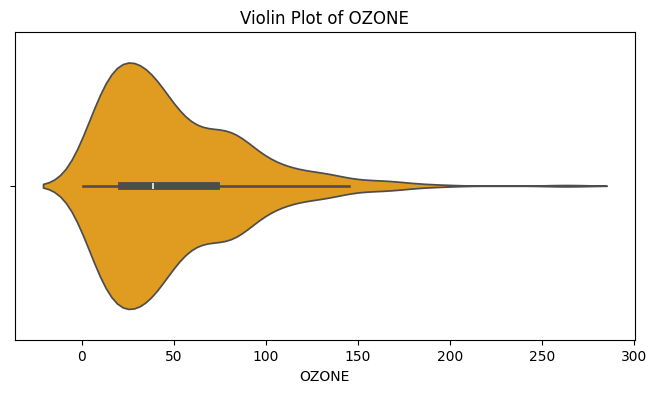

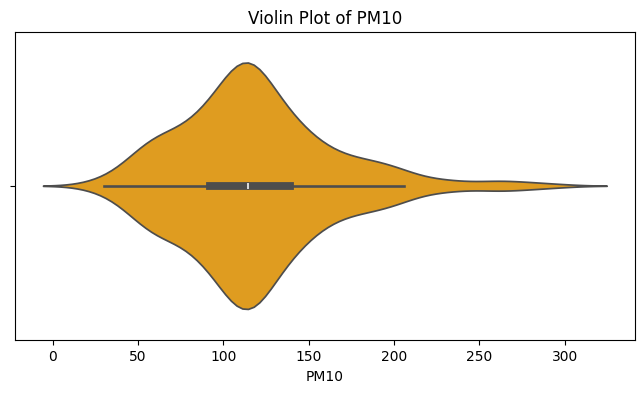

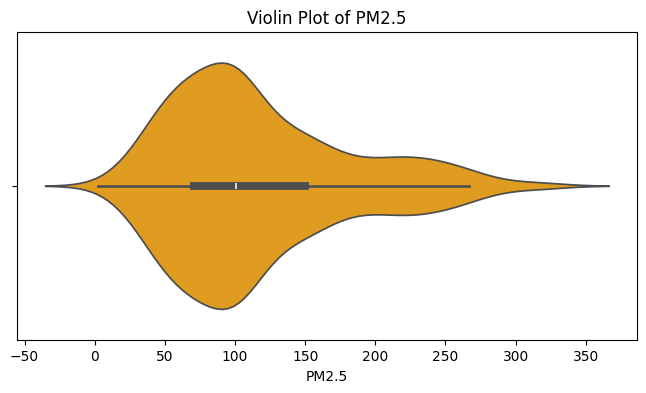

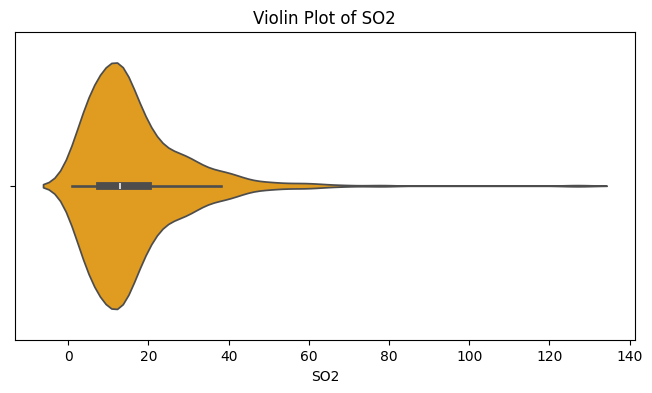

In [ ]:
# violin plot shows distribution and density

for col in pollutants:
    plt.figure(figsize=(8,4))
    sns.violinplot(x=df[col], color='orange')
    plt.title(f"Violin Plot of {col}")
    plt.show()

The violin plot shows how data is distributed and where most values are concentrated. The wider middle area indicates moderate pollution levels, while the thin right tail shows some extreme high values.

## **=> Bivariate Analysis**




**1. Scatter Plot Between Major Pollutants (PM2.5 vs PM10)**

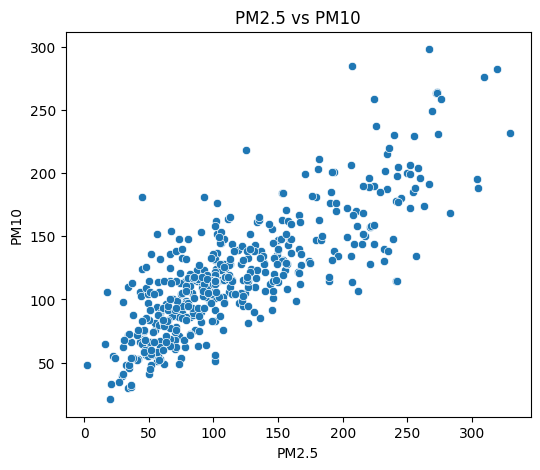

In [ ]:
# PM2.5 vs PM10

plt.figure(figsize=(6,5))
sns.scatterplot(x=df['PM2.5'], y=df['PM10'])
plt.title("PM2.5 vs PM10")
plt.xlabel("PM2.5")
plt.ylabel("PM10")
plt.show()

The scatter plot between PM2.5 and PM10 shows a strong positive linear relationship. This indicates that both pollutants increase together and significantly contribute to overall AQI levels. Since PM2.5 has severe health effects and is strongly correlated with PM10, it plays a crucial role in AQI prediction models and public health risk assessment.

**2. Correlation Heatmap**

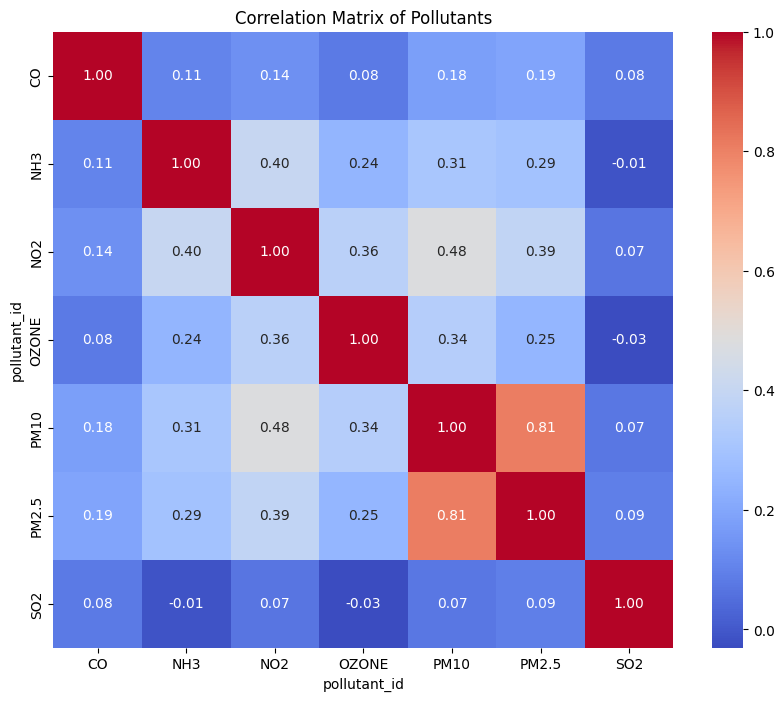

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df[pollutants].corr(),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")
plt.title("Correlation Matrix of Pollutants")
plt.show()

The heatmap clearly shows that particulate matter pollutants (PM2.5 and PM10) are strongly related and play a major role in overall air pollution levels. This is important for AQI prediction, as highly correlated variables indicate common pollution sources and strong influence on air quality.

## **=> Multivariate Analysis**

**1. Pairplot (show all relationships)**

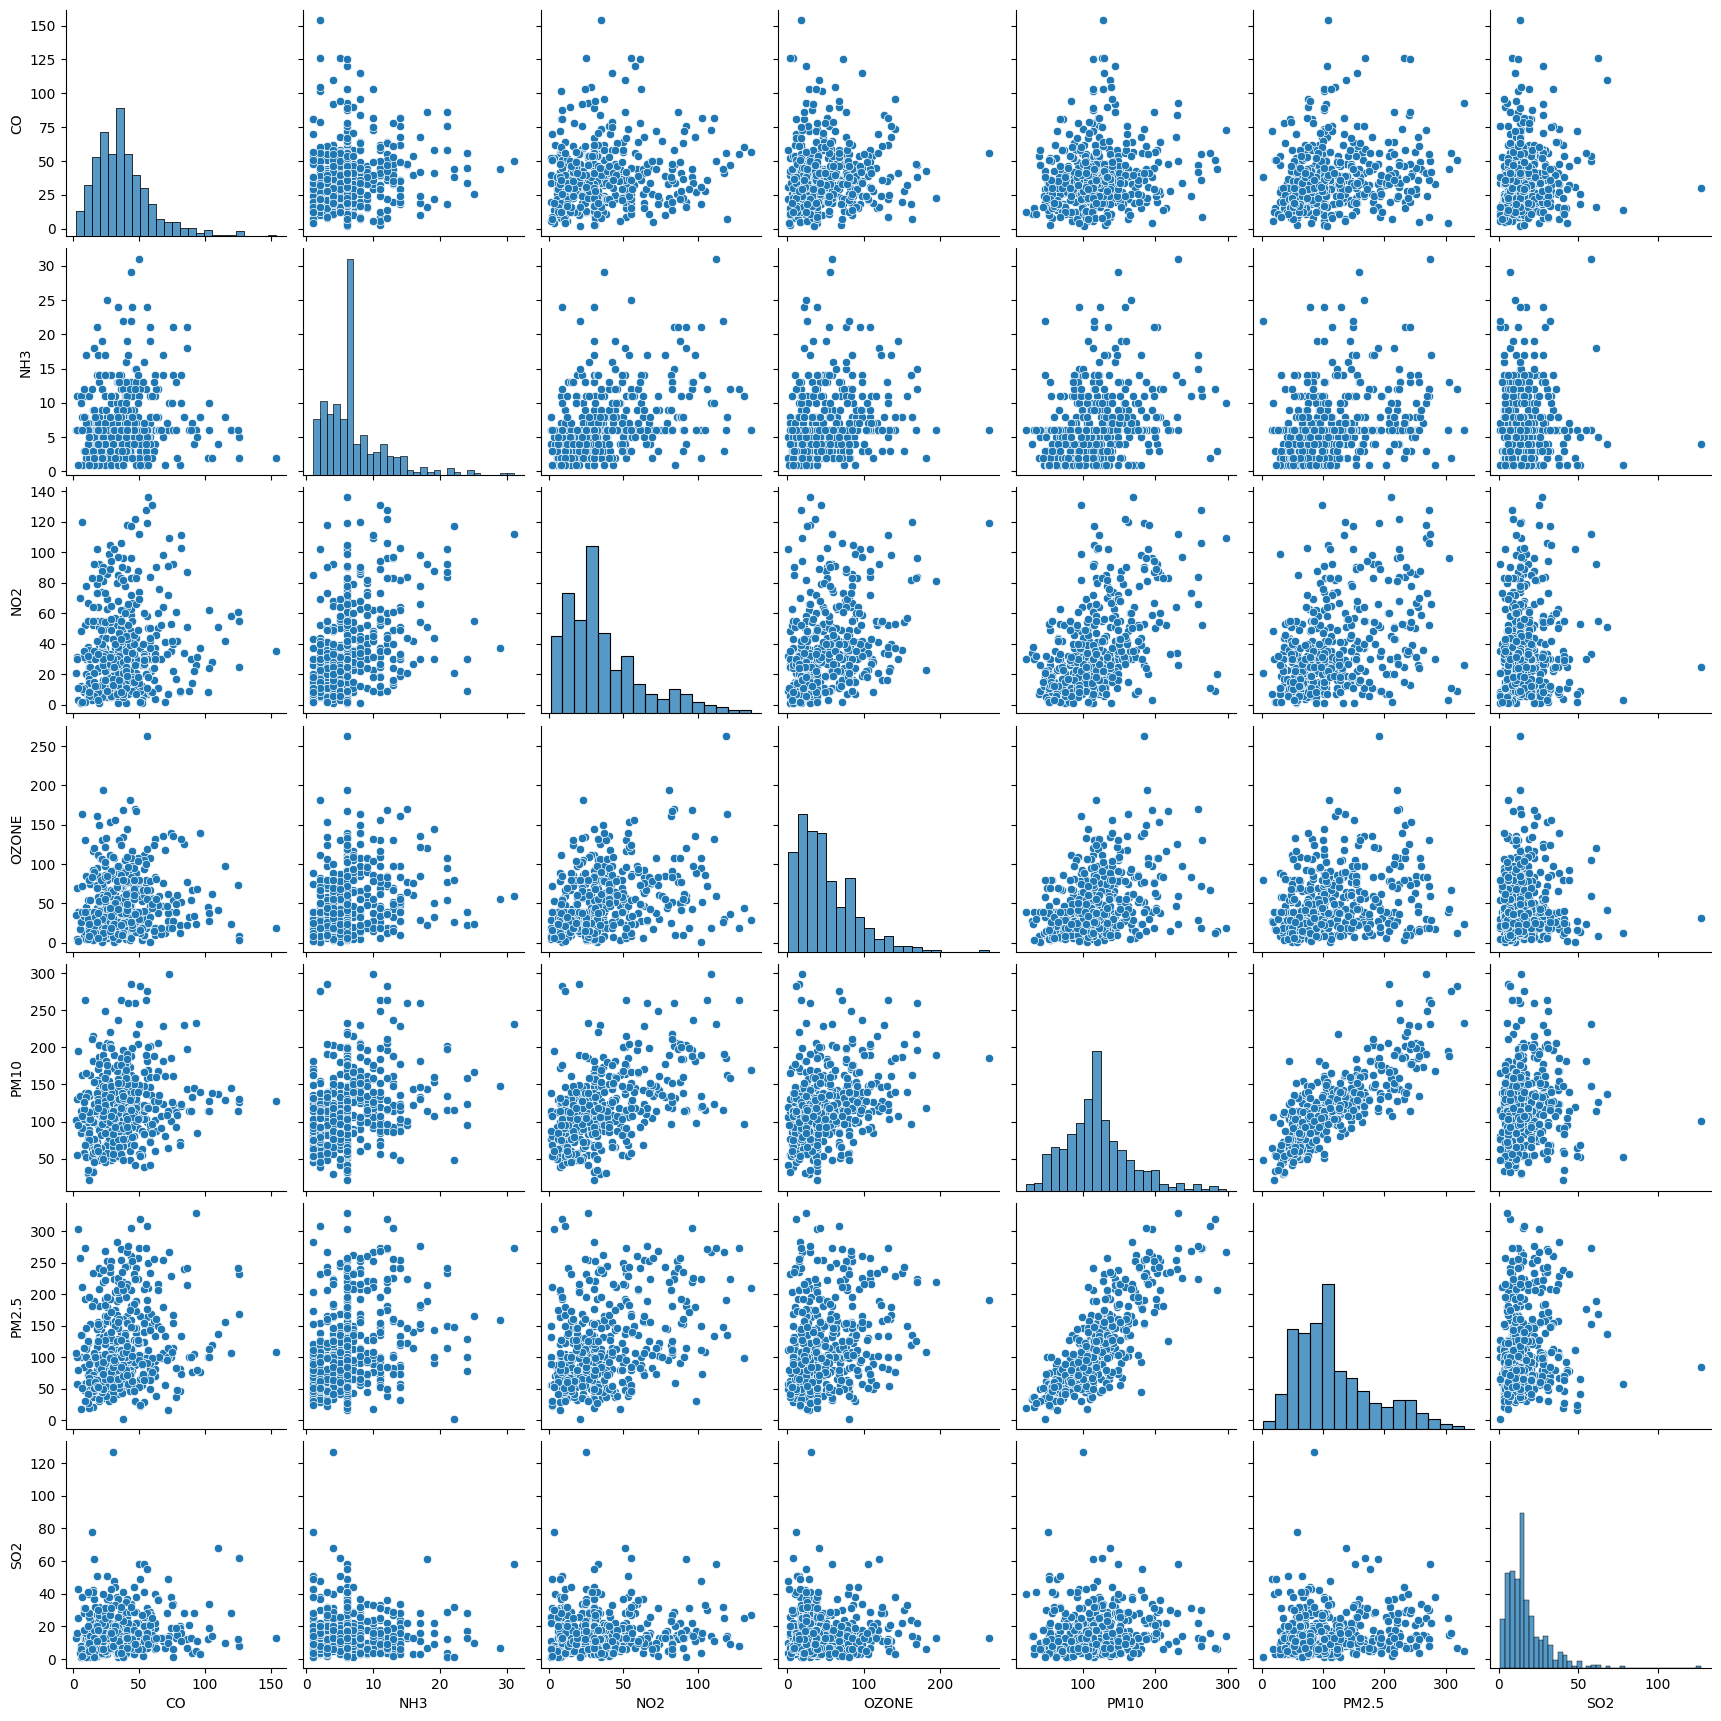

In [ ]:
sns.pairplot(df[pollutants])
plt.show()

Pairplot shows the relationship between all pollutants in one place. It helps to see how one pollutant changes when another pollutant increases or decreases. It also helps to understand if two pollutants are strongly related to each other.

## **=> Categorical vs Numerical Analysis**

**1. Average Pollution by State**

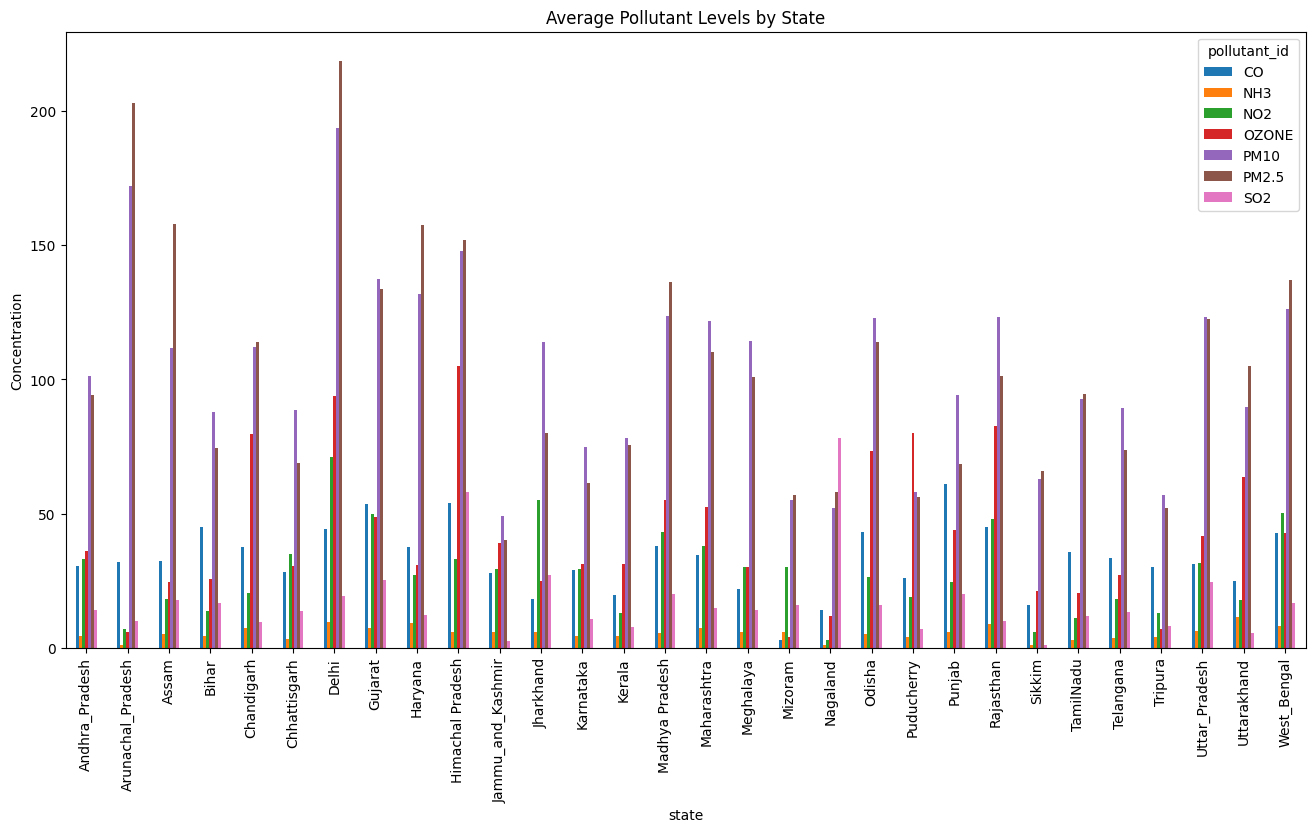

In [ ]:
state_avg = df.groupby('state')[pollutants].mean()

state_avg.plot(kind='bar', figsize=(16,8))
plt.title("Average Pollutant Levels by State")
plt.ylabel("Concentration")
plt.show()

Certain states show consistently higher particulate matter levels, indicating regional pollution patterns.The pollution by state graph shows that some states have consistently higher particulate matter levels. This indicates that pollution is not uniform across the country. Certain regions are more polluted due to industrial activities, traffic, construction, and environmental factors. This is called regional pollution pattern.

**2. Top 10 Most Polluted Cities (PM2.5 Based)**

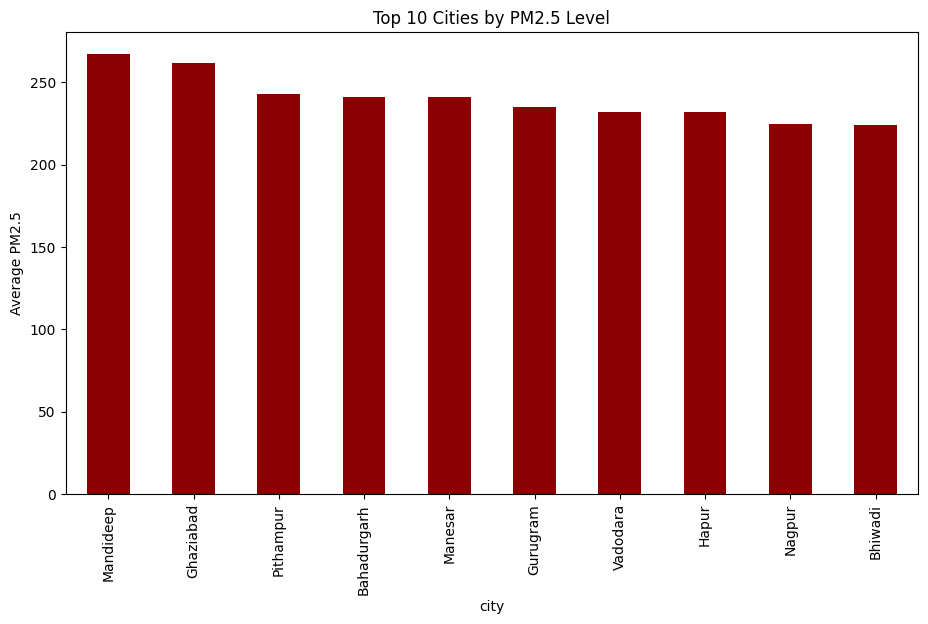

In [ ]:
city_pm25 = df.groupby('city')['PM2.5'].mean().sort_values(ascending=False)

plt.figure(figsize=(11,6))
city_pm25.head(10).plot(kind='bar',color='darkred')
plt.title("Top 10 Cities by PM2.5 Level")
plt.ylabel("Average PM2.5")
plt.show()

This analysis highlights that particulate matter pollution is severe in these cities, and they require stricter pollution control measures. PM2.5 plays a major role in determining AQI and public health risk.

**=> Key Observations**

*   PM2.5 and PM10 show highest variability.
*   Strong positive correlation between particulate pollutants.
*   Significant outliers observed in major cities.
*   Regional variation indicates uneven pollution distribution.
*   Pollution levels fluctuate over time.


## **Selection of Dominant Pollutant**

In [ ]:
corr = df.select_dtypes(include=['number']).corr()

print(corr["PM2.5"].sort_values(ascending=False))

pollutant_id
PM2.5    1.000000
PM10     0.809321
NO2      0.386650
NH3      0.291958
OZONE    0.249073
CO       0.192528
SO2      0.091955
Name: PM2.5, dtype: float64


**From the correlation matrix observed in the EDA section, PM2.5 shows the highest positive correlation with AQI. Therefore, PM2.5 is selected as the dominant pollutant for Machine Learning prediction. Predicting PM2.5 helps simulate real-world scenarios where sensor data may be unavailable.**

## **Define Features (X) and Target Variable (y)**

**Features Used for Prediction**

PM10 ,NO2 ,SO2 ,CO ,NH3 ,OZONE

**Target Variable**

PM2.5 concentration is used as the target variable.

In [ ]:
pollutants = ['CO','NH3','NO2','OZONE','PM10','SO2']

# define target variable
y = df['PM2.5']
X = df[pollutants]

# display the shape
print("Feature columns:", X.columns)
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature columns: Index(['CO', 'NH3', 'NO2', 'OZONE', 'PM10', 'SO2'], dtype='object', name='pollutant_id')
Feature shape: (484, 6)
Target shape: (484,)


PM2.5 was selected as the target variable (y) because it is a major pollutant affecting air quality. The other pollutants (CO, NH3, NO2, OZONE, PM10, SO2) were selected as input features (X) to predict PM2.5 concentration.

## **Train-Test Split**

### Prediction Type

This is a **Regression problem** because the target variable **PM2.5 concentration** is a continuous numerical value.

Regression algorithms are used to predict numerical values based on relationships between dependent and independent variables.

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (387, 6)
Testing size: (97, 6)


The dataset was split into training (80%) and testing (20%) sets.
387 records were used to train the model, while 97 records were used to evaluate its performance on unseen data. This helps ensure that the model generalizes well and does not overfit the training data.

## **Model Building**

:### **1. Train Linear Regression **

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Prediction
y_pred_lr = lr_model.predict(X_test)


### **2. Evaluate Linear Regression**

In [ ]:
# Evaluation
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = mse_lr ** 0.5
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results:")
print("MSE:", mse_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression Results:
MSE: 1329.2301391952951
RMSE: 36.45860857459175
R2 Score: 0.7327006294893945


Linear Regression achieved an R² score of 0.733, which means the model explains about 73% of the variation in PM2.5 levels. The RMSE value of 36.46 shows that the predicted values differ from the actual values by around 36 units on average. This indicates that the model performs reasonably well but is not perfectly accurate.

### **3. Train Decision Tree**

In [ ]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Prediction
y_pred_dt = dt_model.predict(X_test)


### **4. Evaluate Decision Tree**

In [ ]:
# Evaluation
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = mse_dt ** 0.5
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results:")
print("MSE:", mse_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

Decision Tree Results:
MSE: 2380.958762886598
RMSE: 48.79506904274855
R2 Score: 0.5212049743947376


The Decision Tree model achieved an R² score of 0.521, meaning it explains about 52% of the variation in PM2.5 levels. The RMSE value of 48.79 indicates that the predictions differ from the actual values by around 49 units on average.

### **5. Train Random Forest**

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Prediction
y_pred_rf = rf_model.predict(X_test)


### **6. Evaluate Random Forest**

In [ ]:
# Evaluation
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mse_rf ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results:")
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Results:
MSE: 1216.0549474226805
RMSE: 34.87197940213146
R2 Score: 0.7554594104003893


The Random Forest model achieved an R² score of 0.755, meaning it explains about 75.5% of the variation in PM2.5 levels. The RMSE value of 34.87 indicates that the predictions differ from actual values by around 35 units on average.

## **Model Evaluation**

In [ ]:

# demonstrates analytical thinking by comparing Linear Regression ,Decision Tree and Random Forest.

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MAE': [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_dt),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_dt)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ],
    'R2': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf)
    ]
})

print(results)

               Model        MAE       RMSE        R2
0  Linear Regression  27.507562  36.458609  0.732701
1      Decision Tree  36.381443  48.795069  0.521205
2      Random Forest  26.644845  34.871979  0.755459


The performance of all regression models was compared using MAE, RMSE, and R² metrics. Random Forest achieved the highest R² score (0.755) and the lowest MAE (26.64) and RMSE (34.87), indicating better predictive accuracy and lower error compared to other models. Therefore, Random Forest was selected as the final model for predicting PM2.5 concentration.

## **Check Overfitting**

In [ ]:
# Training prediction
train_pred_rf = rf_model.predict(X_train)

# Calculate R2
train_r2 = r2_score(y_train, train_pred_rf)
test_r2 = r2_rf   # already calculated

print("Training R2:", train_r2)
print("Testing R2:", test_r2)

Training R2: 0.9438939771869189
Testing R2: 0.7554594104003893


The Random Forest model achieved a training R² of 0.944 and a testing R² of 0.755. The higher training score indicates that the model fits the training data very well. However, the lower testing score suggests a moderate level of overfitting. Despite this, the model still generalizes reasonably well to unseen data and maintains good predictive performance.

## **Feature Importance**

In [ ]:
# this will show witch pollutant affects PM2.5 most

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

pollutant_id
PM10     0.716268
CO       0.065041
NO2      0.061943
OZONE    0.058831
SO2      0.058101
NH3      0.039817
dtype: float64


This step calculates feature importance using the Random Forest model. Feature importance shows which pollutant has the greatest impact on predicting PM2.5 concentration. Higher importance values indicate stronger influence on the target variable.

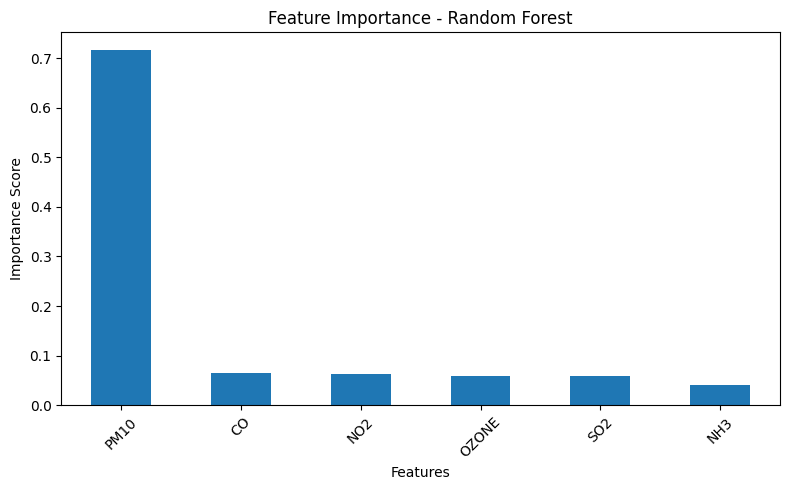

In [ ]:
# Feature Importance Plot

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)

feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(8,5))
feature_importance.plot(kind='bar')

plt.title("Feature Importance - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The bar chart shows the relative importance of each feature in predicting PM2.5. Higher bars indicate stronger influence on the prediction.

## **Actual vs Predicted**

In [ ]:
# Create dataframe for comparison

comparison_df = pd.DataFrame({
    "Actual_PM2.5": y_test,
    "Predicted_PM2.5": y_pred_rf
})

comparison_df.head(10)

,Actual_PM2.5,Predicted_PM2.5
418,51.0,40.82
474,256.0,230.33
181,36.0,33.29
446,211.0,163.30
297,91.0,95.85
148,241.0,182.83
380,126.0,140.04
386,88.0,82.56
479,216.0,143.91
227,93.0,102.04


The comparison between actual and predicted PM2.5 values shows that the model performs well for low and moderate pollution levels. However, for very high PM2.5 values, the model tends to slightly underestimate the concentration. Overall, the predictions are reasonably close to the actual values, indicating good model performance.

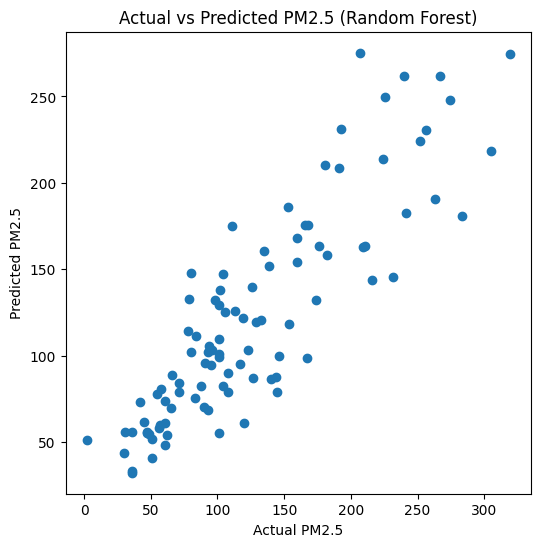

In [ ]:
# plot the actual vs predictable graph

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Actual vs Predicted PM2.5 (Random Forest)")
plt.show()

The Actual vs Predicted scatter plot shows that the Random Forest model performs well in predicting PM2.5 values. The predictions are closely aligned with actual values, especially for low and moderate pollution levels. However, for very high PM2.5 concentrations, the model slightly underestimates the values. Overall, the model demonstrates good accuracy and reliable performance.

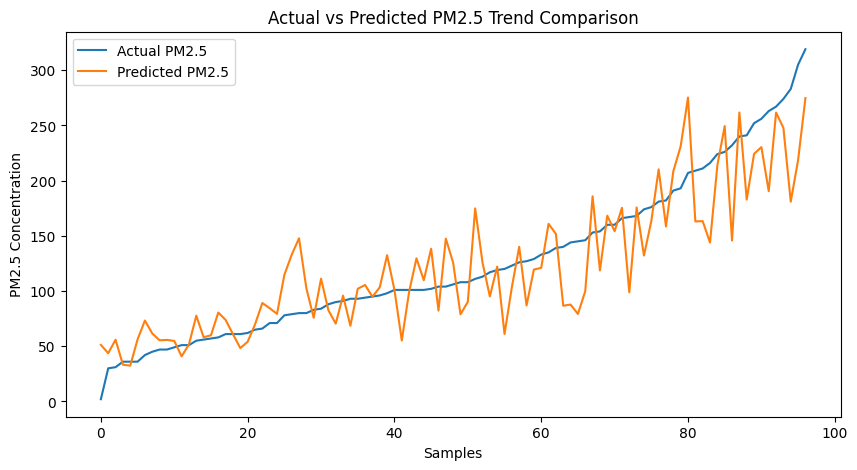

In [ ]:
# Line Plot for Actual vs Predicted Trend

comparison_df = pd.DataFrame({
    "Actual_PM2.5": y_test,
    "Predicted_PM2.5": y_pred_rf
})

# Sort values for smooth visualization
sorted_df = comparison_df.sort_values(by="Actual_PM2.5")

plt.figure(figsize=(10,5))

plt.plot(sorted_df["Actual_PM2.5"].values, label="Actual PM2.5")
plt.plot(sorted_df["Predicted_PM2.5"].values, label="Predicted PM2.5")

plt.title("Actual vs Predicted PM2.5 Trend Comparison")
plt.xlabel("Samples")
plt.ylabel("PM2.5 Concentration")

plt.legend()

plt.show()

This line plot shows the comparison between actual PM2.5 values and the predicted values generated by the model. If the predicted line follows the actual line closely, it means the model is able to capture the overall trend of air pollution levels effectively.

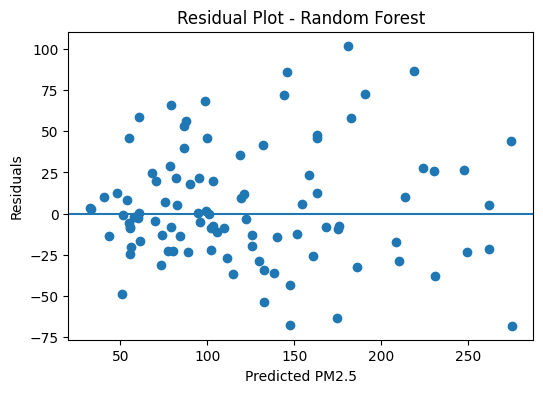

In [ ]:
# Residual Plot

residuals = y_test - y_pred_rf

plt.figure(figsize=(6,4))
plt.scatter(y_pred_rf, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted PM2.5")
plt.ylabel("Residuals")
plt.title("Residual Plot - Random Forest")
plt.show()

Residuals represent the difference between actual and predicted values.
Most residuals are randomly distributed around zero, indicating that the model does not show systematic bias.

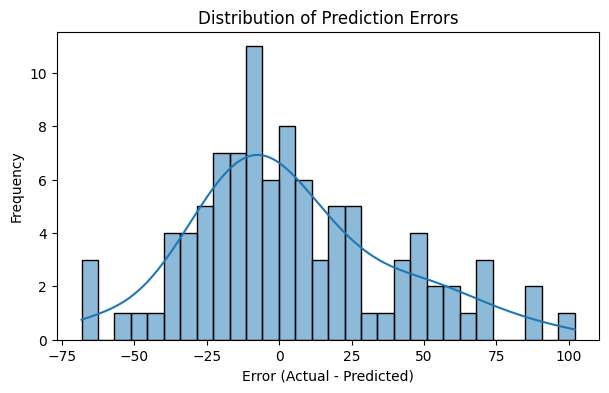

In [ ]:
# Error Distribution Plot

errors = y_test - y_pred_rf

plt.figure(figsize=(7,4))

sns.histplot(errors, bins=30, kde=True)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")

plt.show()

This histogram shows the distribution of prediction errors, which are calculated as Actual value − Predicted value. Most of the errors are concentrated around zero, which means the model predictions are close to the actual PM2.5 values. A smaller spread of errors indicates that the model is performing reasonably well with good prediction accuracy.

## **Add Predicted PM2.5 values in dataset**

In [ ]:
df["Predicted_PM2.5"] = rf_model.predict(X)
df.head()

pollutant_id,country,state,city,station,last_update,CO,NH3,NO2,OZONE,PM10,PM2.5,SO2,Predicted_PM2.5
0,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",2026-02-14 20:00:00,38.0,5.0,51.0,58.0,164.0,111.0,17.0,174.82
1,India,Andhra_Pradesh,Anantapur,"Gulzarpet, Anantapur - APPCB",2026-02-14 20:00:00,31.0,5.0,21.0,17.0,76.0,86.0,8.0,81.46
2,India,Andhra_Pradesh,Chittoor,"Gangineni Cheruvu, Chittoor - APPCB",2026-02-14 20:00:00,36.0,3.0,13.0,69.0,51.0,56.0,11.0,61.85
3,India,Andhra_Pradesh,Kadapa,"Yerramukkapalli, Kadapa - APPCB",2026-02-14 20:00:00,11.0,4.0,21.0,14.0,92.0,72.0,12.0,78.07
4,India,Andhra_Pradesh,Rajamahendravaram,"Anand Kala Kshetram, Rajamahendravaram - APPCB",2026-02-14 20:00:00,33.0,5.0,36.0,31.0,115.0,105.0,12.0,107.51


## **Feature Engineering : Calculate AQI Using Government (CPCB) Formula**

In [ ]:
# Convert CO from µg/m³ to mg/m³
df['CO'] = df['CO'] / 1000

Descriptive statistical analysis revealed that CO values exceeded CPCB breakpoint limits.CPCB defines CO breakpoints in mg/m³, while the dataset provided CO in µg/m³. Therefore, unit conversion was performed to maintain consistency before AQI computation.

### **=> Define CPCB Breakpoints**

In [ ]:
# CPCB Breakpoints (India)


breakpoints = {

    'Predicted_PM2.5': [
        (0, 30, 0, 50),
        (30, 60, 51, 100),
        (60, 90, 101, 200),
        (90, 120, 201, 300),
        (120, 250, 301, 400),
        (250, 1000, 401, 500)
    ],

    'PM10': [
        (0, 50, 0, 50),
        (50, 100, 51, 100),
        (100, 250, 101, 200),
        (250, 350, 201, 300),
        (350, 430, 301, 400),
        (430, 1000, 401, 500)
    ],

    'NO2': [
        (0, 40, 0, 50),
        (40, 80, 51, 100),
        (80, 180, 101, 200),
        (180, 280, 201, 300),
        (280, 400, 301, 400),
        (400, 1000, 401, 500)
    ],

    'SO2': [
        (0, 40, 0, 50),
        (40, 80, 51, 100),
        (80, 380, 101, 200),
        (380, 800, 201, 300),
        (800, 1600, 301, 400),
        (1600, 2000, 401, 500)
    ],

    'CO': [   # CO must be in mg/m³
        (0, 1, 0, 50),
        (1, 2, 51, 100),
        (2, 10, 101, 200),
        (10, 17, 201, 300),
        (17, 34, 301, 400),
        (34, 50, 401, 500)
    ],

    'OZONE': [
        (0, 50, 0, 50),
        (50, 100, 51, 100),
        (100, 168, 101, 200),
        (168, 208, 201, 300),
        (208, 748, 301, 400),
        (748, 1000, 401, 500)
    ]
}

We used CPCB breakpoints because AQI is calculated using official Government interpolation formula. Breakpoints convert pollutant concentration into standardized AQI scale, making pollutants comparable and ensuring accurate health impact classification.

### **=> Sub-Index Function (Interpolation Formula)**

In [ ]:
# linear interpolation formula

pollutants = ['CO','NH3','NO2','OZONE','PM10','SO2','Predicted_PM2.5']

def calculate_subindex(conc, pollutant):

    if pd.isna(conc):
        return np.nan

    for BP_LO, BP_HI, I_LO, I_HI in breakpoints[pollutant]:
        if BP_LO <= conc < BP_HI:
            return ((I_HI - I_LO) / (BP_HI - BP_LO)) * (conc - BP_LO) + I_LO

    # If value exceeds highest range
    if conc >= breakpoints[pollutant][-1][1]:
        return 500

    return np.nan

A function was developed to compute pollutant sub-index values using CPCB breakpoint ranges and linear interpolation formula. This converts pollutant concentration into standardized AQI scale (0–500).

### **=> Apply to Dataset**

In [ ]:
#  Calculated subindex
pollutants = ['Predicted_PM2.5','PM10','NO2','SO2','CO','OZONE']

for pollutant in pollutants:
    df[pollutant + '_SubIndex'] = df[pollutant].apply(
        lambda x: calculate_subindex(x, pollutant)
    )

df.head()

pollutant_id,country,state,city,station,last_update,CO,NH3,NO2,OZONE,PM10,PM2.5,SO2,Predicted_PM2.5,Predicted_PM2.5_SubIndex,PM10_SubIndex,NO2_SubIndex,SO2_SubIndex,CO_SubIndex,OZONE_SubIndex
0,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",2026-02-14 20:00:00,0.038,5.0,51.0,58.0,164.0,111.0,17.0,174.82,342.747538,143.24,64.475,21.25,1.90,58.84
1,India,Andhra_Pradesh,Anantapur,"Gulzarpet, Anantapur - APPCB",2026-02-14 20:00:00,0.031,5.0,21.0,17.0,76.0,86.0,8.0,81.46,171.818000,76.48,26.250,10.00,1.55,17.00
2,India,Andhra_Pradesh,Chittoor,"Gangineni Cheruvu, Chittoor - APPCB",2026-02-14 20:00:00,0.036,3.0,13.0,69.0,51.0,56.0,11.0,61.85,107.105000,51.98,16.250,13.75,1.80,69.62
3,India,Andhra_Pradesh,Kadapa,"Yerramukkapalli, Kadapa - APPCB",2026-02-14 20:00:00,0.011,4.0,21.0,14.0,92.0,72.0,12.0,78.07,160.631000,92.16,26.250,15.00,0.55,14.00
4,India,Andhra_Pradesh,Rajamahendravaram,"Anand Kala Kshetram, Rajamahendravaram - APPCB",2026-02-14 20:00:00,0.033,5.0,36.0,31.0,115.0,105.0,12.0,107.51,258.783000,110.90,45.000,15.00,1.65,31.00


Sub-index values were computed for all pollutants by applying the CPCB interpolation formula to each concentration value.

### **=> Final AQI**

In [ ]:
# AQI calculation

subindex_cols = [p + '_SubIndex' for p in pollutants]

df['AQI'] = df[subindex_cols].max(axis=1)
df.head()

pollutant_id,country,state,city,station,last_update,CO,NH3,NO2,OZONE,PM10,PM2.5,SO2,Predicted_PM2.5,Predicted_PM2.5_SubIndex,PM10_SubIndex,NO2_SubIndex,SO2_SubIndex,CO_SubIndex,OZONE_SubIndex,AQI
0,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",2026-02-14 20:00:00,0.038,5.0,51.0,58.0,164.0,111.0,17.0,174.82,342.747538,143.24,64.475,21.25,1.90,58.84,342.747538
1,India,Andhra_Pradesh,Anantapur,"Gulzarpet, Anantapur - APPCB",2026-02-14 20:00:00,0.031,5.0,21.0,17.0,76.0,86.0,8.0,81.46,171.818000,76.48,26.250,10.00,1.55,17.00,171.818000
2,India,Andhra_Pradesh,Chittoor,"Gangineni Cheruvu, Chittoor - APPCB",2026-02-14 20:00:00,0.036,3.0,13.0,69.0,51.0,56.0,11.0,61.85,107.105000,51.98,16.250,13.75,1.80,69.62,107.105000
3,India,Andhra_Pradesh,Kadapa,"Yerramukkapalli, Kadapa - APPCB",2026-02-14 20:00:00,0.011,4.0,21.0,14.0,92.0,72.0,12.0,78.07,160.631000,92.16,26.250,15.00,0.55,14.00,160.631000
4,India,Andhra_Pradesh,Rajamahendravaram,"Anand Kala Kshetram, Rajamahendravaram - APPCB",2026-02-14 20:00:00,0.033,5.0,36.0,31.0,115.0,105.0,12.0,107.51,258.783000,110.90,45.000,15.00,1.65,31.00,258.783000


In [ ]:
# check AQI column
print(df['AQI'].isna().sum() > 0)

False


The final AQI was computed by selecting the maximum sub-index value among all pollutants, as per CPCB guidelines. This ensures that the pollutant with highest health impact determines overall air quality.

Instead of using actual PM2.5 values, the predicted PM2.5 values obtained from the Random Forest regression model were used to compute AQI. This enables forecasting of air quality levels based on pollutant patterns, making the system predictive rather than descriptive.

## **AQI Categorization (Health Impact)**

In [ ]:
# give categories explain health risk

def aqi_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"

df['AQI_Category'] = df['AQI'].apply(aqi_category)
df.head()

pollutant_id,country,state,city,station,last_update,CO,NH3,NO2,OZONE,PM10,...,SO2,Predicted_PM2.5,Predicted_PM2.5_SubIndex,PM10_SubIndex,NO2_SubIndex,SO2_SubIndex,CO_SubIndex,OZONE_SubIndex,AQI,AQI_Category
0,India,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",2026-02-14 20:00:00,0.038,5.0,51.0,58.0,164.0,...,17.0,174.82,342.747538,143.24,64.475,21.25,1.90,58.84,342.747538,Very Poor
1,India,Andhra_Pradesh,Anantapur,"Gulzarpet, Anantapur - APPCB",2026-02-14 20:00:00,0.031,5.0,21.0,17.0,76.0,...,8.0,81.46,171.818000,76.48,26.250,10.00,1.55,17.00,171.818000,Moderate
2,India,Andhra_Pradesh,Chittoor,"Gangineni Cheruvu, Chittoor - APPCB",2026-02-14 20:00:00,0.036,3.0,13.0,69.0,51.0,...,11.0,61.85,107.105000,51.98,16.250,13.75,1.80,69.62,107.105000,Moderate
3,India,Andhra_Pradesh,Kadapa,"Yerramukkapalli, Kadapa - APPCB",2026-02-14 20:00:00,0.011,4.0,21.0,14.0,92.0,...,12.0,78.07,160.631000,92.16,26.250,15.00,0.55,14.00,160.631000,Moderate
4,India,Andhra_Pradesh,Rajamahendravaram,"Anand Kala Kshetram, Rajamahendravaram - APPCB",2026-02-14 20:00:00,0.033,5.0,36.0,31.0,115.0,...,12.0,107.51,258.783000,110.90,45.000,15.00,1.65,31.00,258.783000,Poor


In [ ]:
# calculate percentage of each category

df['AQI_Category'].value_counts(normalize=True) * 100

,proportion
AQI_Category,
Very Poor,34.090909
Moderate,25.000000
Poor,25.000000
Satisfactory,13.016529
Severe,2.685950
Good,0.206612


The distribution of AQI categories reveals that 34% of observations fall under the Very Poor category, indicating severe air quality concerns. Additionally, 50% of data lies in Moderate and Poor categories combined, suggesting that pollution levels frequently exceed safe thresholds. Only 0.2% of observations were classified as Good, highlighting the persistent nature of air pollution in the study area. These findings emphasize the need for effective pollution control and monitoring strategies.

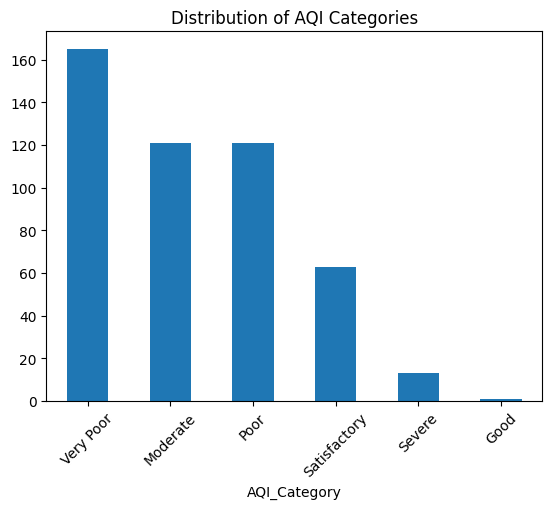

In [ ]:
# To visually analyze health impact distribution.

plt.figure()
df['AQI_Category'].value_counts().plot(kind='bar')
plt.xticks(rotation=45)
plt.title("Distribution of AQI Categories")
plt.show()

AQI values were categorized into six health impact levels as defined by CPCB guidelines. This classification helps interpret the severity of air pollution and its potential health effects. Majority of observations were found in the Moderate and Poor categories, indicating significant air quality concerns.

## **Conclusion**



In this project, air pollution data was analyzed to understand the relationship between different pollutants and PM2.5 concentration. Exploratory Data Analysis helped identify important features affecting PM2.5 levels. Machine learning models were used to predict PM2.5, and their performance was evaluated using regression metrics. The predicted PM2.5 values were further used to calculate the Air Quality Index (AQI) and classify air quality levels. The results show that machine learning techniques can effectively help in predicting pollution levels and support better air quality monitoring and management.